In [48]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Text Encoder

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


class RNNEncoder(nn.Module):
    def __init__(self, ntoken, ninput=300, drop_prob=0.5,
                 nhidden=128, nlayers=1, bidirectional=True):
        super().__init__()
        self.n_steps = 18
        self.ntoken = ntoken  # size of the dictionary
        self.ninput = ninput  # size of each embedding vector
        self.drop_prob = drop_prob  # probability of an element to be zeroed
        self.nlayers = nlayers  # Number of recurrent layers
        self.bidirectional = bidirectional
        if bidirectional:
            self.num_directions = 2
        else:
            self.num_directions = 1
        # number of features in the hidden state
        self.nhidden = nhidden // self.num_directions

        self.encoder = nn.Embedding(self.ntoken, self.ninput)
        self.drop = nn.Dropout(self.drop_prob)

        # dropout: If non-zero, introduces a dropout layer on
        # the outputs of each RNN layer except the last layer
        self.rnn = nn.LSTM(self.ninput, self.nhidden,
                           self.nlayers, batch_first=True,
                           dropout=self.drop_prob,
                           bidirectional=self.bidirectional)


    def forward(self, captions, cap_lens):

        emb = self.drop(self.encoder(captions))

        cap_lens = cap_lens.data.tolist()
        emb = pack_padded_sequence(emb, cap_lens, batch_first=True)

        output, hidden = self.rnn(emb)

        output = pad_packed_sequence(output, batch_first=True)[0]
        words_emb = output.transpose(1, 2)

        sent_emb = hidden[0].transpose(0, 1).contiguous()
        sent_emb = sent_emb.view(-1, self.nhidden * self.num_directions)
        return sent_emb, words_emb

    @staticmethod
    def load(weights_path: str, ntoken: int) -> 'RNNEncoder':
        text_encoder = RNNEncoder(ntoken, nhidden=256)
        state_dict = torch.load(weights_path, map_location=lambda storage, loc: storage)
        text_encoder.load_state_dict(state_dict)
        return text_encoder


# Generator

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

class AffineBlock(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.gamma_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )
        self.beta_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )
        self._xavier_normal_initialization()

    def _xavier_normal_initialization(self):
        for module in self.gamma_mlp.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.constant_(module.bias, val=0)
        for module in self.beta_mlp.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_normal_(module.weight)
                nn.init.constant_(module.bias, val=0)

    def forward(self, x: Tensor, sentence_embed: Tensor) -> Tensor:
        scale_param = self.gamma_mlp(sentence_embed)
        shift_param = self.beta_mlp(sentence_embed)
        scale_param = scale_param.unsqueeze(-1).unsqueeze(-1).expand_as(x)
        shift_param = shift_param.unsqueeze(-1).unsqueeze(-1).expand_as(x)
        return scale_param * x + shift_param

class ResidualBlockG(nn.Module):
    def __init__(self, df_1_c_out: int, df_2_c_out: int, affine_h_d: int = 128, df_1_c_in: int = 256, df_2_c_in: int = 256):
        super().__init__()
        self.fusion_block_1 = AffineBlock(input_dim=df_1_c_in, hidden_dim=affine_h_d, output_dim=df_1_c_out)
        self.conv_1 = nn.Conv2d(df_1_c_out, df_2_c_out, kernel_size=3, stride=1, padding=1)
        
        self.fusion_block_3 = AffineBlock(input_dim=df_2_c_in, hidden_dim=affine_h_d, output_dim=df_2_c_out)
        self.conv_2 = nn.Conv2d(df_2_c_out, df_2_c_out, kernel_size=3, stride=1, padding=1)

        self.scale_conv = None
        if df_1_c_out != df_2_c_out:
            self.scale_conv = nn.Conv2d(df_1_c_out, df_2_c_out, kernel_size=1, stride=1, padding=0)

        self.gamma = nn.Parameter(torch.zeros(1))

    def _shortcut(self, x: Tensor) -> Tensor:
        if self.scale_conv is not None:
            x = self.scale_conv(x)
        return x

    def _df_block_1(self, x: Tensor, sentence_embed: Tensor) -> Tensor:
        h = self.fusion_block_1(x, sentence_embed)
        h = F.leaky_relu(h, 0.2, inplace=True)
        return self.conv_1(h)

    def _df_block_2(self, x: Tensor, sentence_embed: Tensor) -> Tensor:
        h = self.fusion_block_3(x, sentence_embed)
        h = F.leaky_relu(h, 0.2, inplace=True)
        return self.conv_2(h)

    def _residual(self, x: Tensor, y: Tensor) -> Tensor:
        h_1 = self._df_block_1(x, y)
        h_2 = self._df_block_2(h_1, y)
        return h_2

    def forward(self, x: Tensor, sentence_embed: Tensor) -> Tensor:
        return self._shortcut(x) + self.gamma * self._residual(x, sentence_embed)

class GlobalAttentionGeneral(nn.Module):
    def __init__(self, idf, cdf):
        super(GlobalAttentionGeneral, self).__init__()
        self.conv_context = nn.Conv1d(cdf, idf, kernel_size=1)
        self.sm = nn.Softmax(dim=1)

    def forward(self, input: Tensor, context: Tensor) -> Tensor:
        # input shape: [batch, channels, height, width]
        # context shape: [batch, word_features, num_words]
        
        batch_size, channels, height, width = input.size()
        num_words = context.size(2)
        
        # Reshape input to [batch, channels, height*width]
        target = input.view(batch_size, channels, -1)  # [B, C, H*W]
        
        # Process context (word embeddings)
        source = self.conv_context(context)  # [B, C, num_words]
        
        # Compute attention
        attn = torch.bmm(source.transpose(1, 2), target)  # [B, num_words, H*W]
        attn = self.sm(attn)
        
        # Compute weighted context
        weighted_context = torch.bmm(source, attn)  # [B, C, H*W]
        weighted_context = weighted_context.view(batch_size, channels, height, width)
        
        return weighted_context, attn.view(batch_size, -1, height, width)

class GLU(nn.Module):
    def __init__(self):
        super(GLU, self).__init__()

    def forward(self, x):
        nc = x.size(1)
        assert nc % 2 == 0, 'channels dont divide 2!'
        nc = int(nc/2)
        return x[:, :nc] * torch.sigmoid(x[:, nc:])

def upBlock(in_planes, out_planes):
    block = nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_planes, out_planes * 2, kernel_size=3, stride=1, padding=1, bias=False),
        nn.BatchNorm2d(out_planes * 2),
        GLU()
    )
    return block
class Generator(nn.Module):
    def __init__(self, n_channels: int = 64, latent_dim: int = 100, use_attention: bool = True):
        super().__init__()
        self.n_channels = n_channels
        
        # Project noise to initial feature map (4x4)
        self.linear_in = nn.Linear(latent_dim, n_channels * 4 * 4 * 4)

        # Define residual blocks with proper text embedding dimension
        self.res_blocks = nn.ModuleList([
            ResidualBlockG(4 * n_channels, 4 * n_channels),
            ResidualBlockG(4 * n_channels, 2 * n_channels),
            ResidualBlockG(2 * n_channels, n_channels),
        ])

        # Attention mechanism
        if use_attention:
            self.att = GlobalAttentionGeneral(idf=n_channels,cdf=256)
            # After attention concatenation, channels will double
            self.att_conv = nn.Conv2d(n_channels * 2, n_channels, kernel_size=1)
        else:
            self.att = None

        # Upsampling blocks for 256x256 output
        self.upsample_blocks = nn.ModuleList([
            upBlock(n_channels, n_channels // 2),         # 32x32 -> 64x64
            upBlock(n_channels // 2, n_channels // 4),    # 64x64 -> 128x128
            upBlock(n_channels // 4, n_channels // 8),    # 128x128 -> 256x256
        ])
        
        self.res_block_out = ResidualBlockG(n_channels // 8, n_channels // 16)
        
        self.conv_out = nn.Sequential(
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_channels // 16, 3, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise_vector: Tensor, sentence_embed: Tensor, word_embed: Tensor) -> Tensor:
        # Initial projection
        out = self.linear_in(noise_vector)
        out = out.view(noise_vector.size(0), 4 * self.n_channels, 4, 4)
        
        # Process through residual blocks with upsampling
        for res_block in self.res_blocks:
            out = res_block(out, sentence_embed)
            out = F.interpolate(out, scale_factor=2, mode='bilinear', align_corners=False)
            
        # Apply attention if needed
        if self.att is not None:
            out_attn, _ = self.att(out, word_embed)
            out = torch.cat((out, out_attn), dim=1)
            out = self.att_conv(out)  # Reduce channels back to n_channels
        
        # Additional upsampling to reach 256x256
        for upsample_block in self.upsample_blocks:
            out = upsample_block(out)
        
        # Final processing
        out = self.res_block_out(out, sentence_embed)
        out = self.conv_out(out)
        
        return out
 



In [52]:
import torch
import torchinfo

gen = Generator(n_channels=32, latent_dim=100)

noise = torch.rand((24, 100))
sent = torch.rand((24, 256))
word = torch.rand((24, 256, 18))

torchinfo.summary(gen, input_data=(noise, sent, word))

Layer (type:depth-idx)                   Output Shape              Param #
Generator                                [24, 3, 256, 256]         --
├─Linear: 1-1                            [24, 2048]                206,848
├─ModuleList: 1-2                        --                        --
│    └─ResidualBlockG: 2-1               [24, 128, 4, 4]           1
│    │    └─AffineBlock: 3-1             [24, 128, 4, 4]           98,816
│    │    └─Conv2d: 3-2                  [24, 128, 4, 4]           147,584
│    │    └─AffineBlock: 3-3             [24, 128, 4, 4]           98,816
│    │    └─Conv2d: 3-4                  [24, 128, 4, 4]           147,584
│    └─ResidualBlockG: 2-2               [24, 64, 8, 8]            1
│    │    └─Conv2d: 3-5                  [24, 64, 8, 8]            8,256
│    │    └─AffineBlock: 3-6             [24, 128, 8, 8]           98,816
│    │    └─Conv2d: 3-7                  [24, 64, 8, 8]            73,792
│    │    └─AffineBlock: 3-8             [24, 64, 8, 

# Discriminator

In [53]:
import torch
import torch.nn as nn
import torchvision.models as models

class PretrainedDiscriminator(nn.Module):
    def __init__(self, n_c: int, sentence_embed_dim: int = 256, pretrained_model=None):
        super().__init__()

        # Load a pretrained ResNet-18 model as feature extractor
        if pretrained_model is None:
            self.feature_extractor = models.resnet18(pretrained=True)
        else:
            self.feature_extractor = pretrained_model

        # Remove the final classification layer (keeping convolutional features)
        self.feature_extractor = nn.Sequential(*list(self.feature_extractor.children())[:-2])

        # Extra convolutional layers after ResNet features
        self.extra_layers = nn.Sequential(
            nn.Conv2d(512, n_c * 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_c * 16, n_c * 16, kernel_size=4, stride=2, padding=1),
            nn.Conv2d(n_c * 16, n_c * 16, kernel_size=4, stride=2, padding=1),
        )

        # Define the number of input channels for final classification
        in_c_logit = 16 * n_c + sentence_embed_dim

        # Final discriminator layers (Image + Sentence Embeddings)
        self.img_sentence_forward = nn.Sequential(
            nn.Conv2d(in_c_logit, n_c * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Changed kernel size from 4 to 2 to match the spatial size (2x2 input -> 1x1 output)
            nn.Conv2d(n_c * 2, 1, kernel_size=2, stride=1, padding=0, bias=False)
        )

    def build_embeds(self, image: torch.Tensor) -> torch.Tensor:
        """
        Extract feature embeddings from the input image using ResNet and additional conv layers.
        Expected output shape: [batch_size, n_c*16, 2, 2] for typical 256x256 inputs.
        """
        out = self.feature_extractor(image)  # [batch_size, 512, h/32, w/32]
        out = self.extra_layers(out)  # Further processing
        return out

    def get_logits(self, image_embed: torch.Tensor, sentence_embed: torch.Tensor) -> torch.Tensor:
        """
        Combine image features and sentence embeddings, then compute real/fake logits.
        """
        # Reshape sentence_embed: [batch, 256] -> [batch, 256, 1, 1] and then repeat to match image spatial dims.
        sentence_embed = sentence_embed.view(-1, 256, 1, 1).repeat(1, 1, image_embed.shape[2], image_embed.shape[3])
        h_c_code = torch.cat((image_embed, sentence_embed), 1)  # Concatenate along channel dimension
        logits = self.img_sentence_forward(h_c_code)
        return logits

    def forward(self, image: torch.Tensor, sentence_embed: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for the discriminator.
        """
        image_embed = self.build_embeds(image)
        logits = self.get_logits(image_embed, sentence_embed)
        return logits


In [54]:
import torch
import torch.nn as nn
import torchvision.models as models

class ShallowResNetDiscriminator(nn.Module):
    def __init__(self, n_c=32, sentence_embed_dim=256):
        super().__init__()
        resnet = models.resnet18(pretrained=True)

        # Use only the first two blocks of ResNet18
        self.feature_extractor = nn.Sequential(
            resnet.conv1,  # Initial conv layer
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,  # First ResNet block
            resnet.layer2,  # Second ResNet block
        )

        # Output channels from layer2 in ResNet-18 is 128
        self.extra_layers = nn.Sequential(
            nn.Conv2d(128, n_c * 16, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_c * 16, n_c * 16, kernel_size=4, stride=2, padding=1),
            nn.Conv2d(n_c * 16, n_c * 16, kernel_size=4, stride=2, padding=1),
        )

        # Final classification layers
        in_c_logit = 16 * n_c + sentence_embed_dim
        self.img_sentence_forward = nn.Sequential(
            nn.Conv2d(in_c_logit, n_c * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(n_c * 2, 1, kernel_size=2, stride=1, padding=0, bias=False)
        )

    def build_embeds(self, image: torch.Tensor) -> torch.Tensor:
        """
        Extract feature embeddings from the input image using ResNet and additional conv layers.
        Expected output shape: [batch_size, n_c*16, 2, 2] for typical 256x256 inputs.
        """
        out = self.feature_extractor(image)  # Shape: [batch, 128, h/4, w/4]
        out = self.extra_layers(out)  # Shape: [batch, n_c*16, 2, 2]
        return out

    def get_logits(self, image_embed: torch.Tensor, sentence_embed: torch.Tensor) -> torch.Tensor:
        """
        Combine image features and sentence embeddings, then compute real/fake logits.
        """
        # Reshape sentence_embed: [batch, 256] -> [batch, 256, 1, 1] and then repeat to match image spatial dims.
        sentence_embed = sentence_embed.view(-1, 256, 1, 1).repeat(1, 1, image_embed.shape[2], image_embed.shape[3])
        h_c_code = torch.cat((image_embed, sentence_embed), 1)  # Concatenate along channel dimension
        logits = self.img_sentence_forward(h_c_code)
        return logits

    def forward(self, image: torch.Tensor, sentence_embed: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for the shallow discriminator.
        """
        image_embed = self.build_embeds(image)
        logits = self.get_logits(image_embed, sentence_embed)
        return logits


In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor


class ResidualBlockD(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.residual_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.scale_conv = None
        if in_channels != out_channels:
            self.scale_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

        self.gamma = nn.Parameter(torch.zeros(1))

    def _shortcut(self, x: Tensor) -> Tensor:
        if self.scale_conv is not None:
            x = self.scale_conv(x)

        return F.avg_pool2d(x, 2)

    def forward(self, x: Tensor) -> Tensor:
        return self._shortcut(x) + self.gamma * self.residual_conv(x)

# Dataset

In [57]:
import os
import pickle
from typing import Dict, List, Optional, Tuple

import numpy as np
import numpy.random as random
import pandas as pd
import torchvision.transforms as transforms
from PIL import Image
from torch import Tensor
from torch.utils.data import Dataset
from torchvision.transforms import Compose


class DFGANDataset(Dataset):
    def __init__(self, data_dir: str, split: str = "train", transform: Optional[Compose] = None):
        self.split = split
        self.data_dir = data_dir

        self.split_dir = os.path.join(data_dir, split)
        self.captions_path = os.path.join(self.data_dir, "captions.pickle")
        self.filenames_path = os.path.join(self.split_dir, "filenames.pickle")

        self.transform = transform

        self.embeddings_num = 10

        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
            # /kaggle/input/cv-seattention/cv_seattention/data/CUB_200_2011/CUB_200_2011/bounding_boxes.txt
        self.images_dir = os.path.join(self.data_dir, "CUB_200_2011/CUB_200_2011/images")
        self.bbox_path = os.path.join(self.data_dir, "CUB_200_2011/CUB_200_2011/bounding_boxes.txt")
        self.images_path = os.path.join(self.data_dir, "CUB_200_2011/CUB_200_2011/images.txt")

        self.bbox = self._load_bbox()

        self.file_names, self.captions, self.code2word, self.word2code = self._load_text_data()

        self.n_words = len(self.code2word)
        self.num_examples = len(self.file_names)

        self._print_info()

    def _print_info(self):
        print(f"Total filenames: {len(self.bbox)}")
        print(f"Load captions from: {self.captions_path}")
        print(f"Load file names from: {self.filenames_path} ({self.num_examples})")
        print(f"Dictionary size: {self.n_words}")
        print(f"Embeddings number: {self.embeddings_num}")

    def _load_bbox(self) -> Dict[str, List[int]]:
        df_bbox = pd.read_csv(self.bbox_path, delim_whitespace=True, header=None).astype(int)

        df_image_names = pd.read_csv(self.images_path, delim_whitespace=True, header=None)
        image_names = df_image_names[1].tolist()

        filename_bbox = dict()
        for i, file_name in enumerate(image_names):
            bbox = df_bbox.iloc[i][1:].tolist()
            filename_bbox[file_name[:-4]] = bbox

        return filename_bbox

    def _load_text_data(self) -> Tuple[List[str], List[List[int]],
                                       Dict[int, str], Dict[str, int]]:
        with open(self.captions_path, 'rb') as file:
            train_captions, test_captions, code2word, word2code = pickle.load(file)

        filenames = self._load_filenames()

        if self.split == 'train':
            return filenames, train_captions, code2word, word2code

        return filenames, test_captions, code2word, word2code

    def _load_filenames(self) -> List[str]:
        if os.path.isfile(self.filenames_path):
            with open(self.filenames_path, 'rb') as file:
                return pickle.load(file)

        raise ValueError(f"File {self.filenames_path} does not exist")

    def _get_caption(self, caption_idx: int) -> Tuple[np.ndarray, int]:
        caption = np.array(self.captions[caption_idx])
        pad_caption = np.zeros((18, 1), dtype='int64')

        if len(caption) <= 18:
            pad_caption[:len(caption), 0] = caption
            return pad_caption, len(caption)

        indices = list(np.arange(len(caption)))
        np.random.shuffle(indices)
        pad_caption[:, 0] = caption[np.sort(indices[:18])]

        return pad_caption, 18

    def _get_image(self, image_path: str, bbox: List[int]) -> Tensor:

        image = Image.open(image_path).convert('RGB')
        width, height = image.size

        r = int(np.maximum(bbox[2], bbox[3]) * 0.75)
        center_x = int((2 * bbox[0] + bbox[2]) / 2)
        center_y = int((2 * bbox[1] + bbox[3]) / 2)

        y1 = np.maximum(0, center_y - r)
        y2 = np.minimum(height, center_y + r)
        x1 = np.maximum(0, center_x - r)
        x2 = np.minimum(width, center_x + r)

        image = image.crop((x1, y1, x2, y2))
        image = self.normalize(self.transform(image))

        return image

    def _get_random_caption(self, idx: int) -> Tuple[np.ndarray, int]:
        caption_shift = random.randint(0, self.embeddings_num-1)
        caption_idx = idx * self.embeddings_num + caption_shift

        if caption_idx >= len(self.captions):
            caption_idx = len(self.captions) - 1 
            
        return self._get_caption(caption_idx)

    def __getitem__(self, idx: int) -> Tuple[Tensor, np.ndarray, int, str]:
        file_name = self.file_names[idx]
        image = self._get_image(f"{self.images_dir}/{file_name}.jpg", self.bbox[file_name])

        encoded_caption, caption_len = self._get_random_caption(idx)

        return image, encoded_caption, caption_len, file_name

    def __len__(self) -> int:
        return self.num_examples

In [58]:
from typing import List, Tuple

import torch
from torch import Tensor


def prepare_data(batch: Tuple[Tensor, Tensor, Tensor, Tuple[str]],
                 device: torch.device) -> Tuple[Tensor, Tensor, Tensor, List[str]]:
    images, captions, captions_len, file_names = batch

    sorted_cap_lens, sorted_cap_indices = torch.sort(captions_len, 0, True)
    sorted_cap_lens = sorted_cap_lens.to(device)

    sorted_images = images[sorted_cap_indices].to(device)
    sorted_captions = captions[sorted_cap_indices].squeeze().to(device)
    sorted_file_names = [file_names[i] for i in sorted_cap_indices.numpy()]

    return sorted_images, sorted_captions, sorted_cap_lens, sorted_file_names


In [59]:
import random
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader,Subset
from torchvision.transforms import transforms

#from objects.dataset import DFGANDataset


def create_loader(imsize: int, batch_size: int, data_dir: str, split: str) -> DataLoader:
    assert split in ["train", "test"], "Wrong split type, expected train or test"
    image_transform = transforms.Compose([
        transforms.Resize(int(imsize * 76 / 64)),
        transforms.RandomCrop(imsize),
        transforms.RandomHorizontalFlip()
    ])

    dataset = DFGANDataset(data_dir, split, image_transform)
    #n_words = dataset.n_words
    #subset_size=4000
    #shuffled_indices = torch.randperm(len(dataset))[:4000].tolist()
    #dataset = Subset(dataset, shuffled_indices)

    #print(len(dataset))

    return DataLoader(dataset, batch_size=batch_size, drop_last=True,shuffle=True)


def fix_seed(seed: int = 123321):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    print(f"Seed {seed} fixed")


In [60]:
import os
from typing import Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.utils as vutils
from torch import Tensor
from torch.utils.data import DataLoader
from tqdm.auto import trange

class DeepFusionGAN:
    def __init__(self, n_words, encoder_weights_path: str, image_save_path: str, gen_path_save: str, use_pretrained_discriminator: bool = True):
        super().__init__()
        self.image_save_path = image_save_path
        self.gen_path_save = gen_path_save
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.generator = Generator(n_channels=32, latent_dim=100).to(self.device)
        
        # if use_pretrained_discriminator:
        #     self.discriminator = PretrainedDiscriminator(n_c=32).to(self.device)  # ✅ Correct
        # else:
        #     self.discriminator = Discriminator(n_c=32).to(self.device)
        if use_pretrained_discriminator:
            self.discriminator = ShallowResNetDiscriminator(n_c=32).to(self.device)  # ✅ Use shallower ResNet
        else:
            self.discriminator = Discriminator(n_c=32).to(self.device)

        self.text_encoder = RNNEncoder.load(encoder_weights_path, n_words).to(self.device)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        self.g_optim = torch.optim.Adam(self.generator.parameters(), lr=0.0003, betas=(0.5, 0.999))
        self.d_optim = torch.optim.Adam(self.discriminator.parameters(), lr=5e-6, betas=(0.5, 0.999))

    def _init_pretrained_discriminator(self):
        # This method is not used when using the PretrainedDiscriminator class.
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, 1)  # Modify for binary classification
        return model.to(self.device)
    
    def _compute_gp(self, images: Tensor, sentence_embeds: Tensor) -> Tensor:
        batch_size = images.shape[0]
        images_interpolated = images.data.requires_grad_()
        sentences_interpolated = sentence_embeds.data.requires_grad_()
        
        embeds = self.discriminator.build_embeds(images_interpolated)
        logits = self.discriminator.get_logits(embeds, sentences_interpolated)
        
        grad_outputs = torch.ones_like(logits)
        grads = torch.autograd.grad(
            outputs=logits,
            inputs=(images_interpolated, sentences_interpolated),
            grad_outputs=grad_outputs,
            retain_graph=True,
            create_graph=True
        )
        
        grad_0 = grads[0].reshape(batch_size, -1)
        grad_1 = grads[1].reshape(batch_size, -1)
        
        grad = torch.cat((grad_0, grad_1), dim=1)
        grad_norm = grad.norm(2, dim=1)
        return grad_norm

    def fit(self, train_loader: DataLoader, num_epochs: int = 500, checkpoint_path: str = None) -> Tuple[List[float], List[float], List[float]]:
        g_losses_epoch, d_losses_epoch, d_gp_losses_epoch = [], [], []
        lambda_gp = 1.0
        start_epoch = 0
    
        if checkpoint_path and os.path.exists(checkpoint_path):
            start_epoch = self._load_gen_weights(checkpoint_path)
            print(f"Resuming from epoch {start_epoch}")
    
        for epoch in trange(start_epoch, num_epochs, desc="Training DeepFusionGAN"):
            g_losses, d_losses, d_gp_losses = [], [], []
            for batch in train_loader:
                images, captions, captions_len, _ = prepare_data(batch, self.device)
                batch_size = images.shape[0]
    
                sentence_embeds, words_embs = self.text_encoder(captions, captions_len)
                sentence_embeds, words_embs = sentence_embeds.detach(), words_embs.detach()
    
                # Discriminator Update
                real_logits = self.discriminator(images, sentence_embeds)
                d_loss_real = -torch.mean(real_logits)
    
                noise = torch.randn(batch_size, 100, device=self.device)
                fake_images = self.generator(noise, sentence_embeds, words_embs)
                fake_logits = self.discriminator(fake_images.detach(), sentence_embeds)
                d_loss_fake = torch.mean(fake_logits)
    
                d_loss_gp = torch.mean((self._compute_gp(images, sentence_embeds) - 1) ** 2)
                d_loss = d_loss_real + d_loss_fake + lambda_gp * d_loss_gp
                
                self.d_optim.zero_grad()
                d_loss.backward()
                self.d_optim.step()
    
                # Generator Update (Twice)
                for _ in range(5):  # Update G 
                    noise = torch.randn(batch_size, 100, device=self.device)
                    fake_images = self.generator(noise, sentence_embeds, words_embs)
                    fake_logits = self.discriminator(fake_images, sentence_embeds)
                    g_loss = -torch.mean(fake_logits)
    
                    self.g_optim.zero_grad()
                    g_loss.backward()
                    self.g_optim.step()
    
                g_losses.append(g_loss.item())
                d_losses.append(d_loss.item())
                d_gp_losses.append(d_loss_gp.item())
    
            g_losses_epoch.append(sum(g_losses) / len(g_losses))
            d_losses_epoch.append(sum(d_losses) / len(d_losses))
            d_gp_losses_epoch.append(sum(d_gp_losses) / len(d_gp_losses))
    
            self._save_fake_image(fake_images, epoch)
            self._save_gen_weights(epoch)
            print(f"Epoch {epoch}: G Loss {g_losses_epoch[-1]:.4f}, D Loss {d_losses_epoch[-1]:.4f}, GP Loss {d_gp_losses_epoch[-1]:.4f}")
    
        return g_losses_epoch, d_losses_epoch, d_gp_losses_epoch

    def _save_fake_image(self, fake_images: Tensor, epoch: int):
        img_path = os.path.join(self.image_save_path, f"fake_wgangp_epoch_{epoch}.png")
        vutils.save_image(fake_images.data, img_path, normalize=True)

    def _save_gen_weights(self, epoch: int):
        gen_path = os.path.join(self.gen_path_save, f"gennormal_{epoch}.pth")
        checkpoint = {
            'epoch': epoch,
            'generator_state_dict': self.generator.state_dict(),
            'discriminator_state_dict': self.discriminator.state_dict(),
            'g_optim_state_dict': self.g_optim.state_dict(),
            'd_optim_state_dict': self.d_optim.state_dict(),
        }
        torch.save(checkpoint, gen_path)
        print(f"Model checkpoint saved at epoch {epoch} to {gen_path}")

    def _load_gen_weights(self, checkpoint_path: str) -> int:
        checkpoint = torch.load(checkpoint_path)
        self.generator.load_state_dict(checkpoint['generator_state_dict'])
        self.discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
        self.g_optim.load_state_dict(checkpoint['g_optim_state_dict'])
        self.d_optim.load_state_dict(checkpoint['d_optim_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Checkpoint loaded from {checkpoint_path} - Starting from epoch {start_epoch}")
        return start_epoch


# train

In [ ]:
import os
from typing import List, Tuple


def train() -> Tuple[List[float], List[float], List[float]]:
    fix_seed()

    data_path = "/kaggle/input/cv-seattention/cv_seattention/data"
    encoder_weights_path = "/kaggle/input/cv-seattention/cv_seattention/text_encoder_weights/text_encoder200.pth"
    image_save_path = "/kaggle/working/gen_weights"
    gen_path_save = "/kaggle/working/gen_weights"

    os.makedirs(image_save_path, exist_ok=True)
    os.makedirs(gen_path_save, exist_ok=True)

    train_loader= create_loader(256, 32, data_path, "train")
    model = DeepFusionGAN(n_words=train_loader.dataset.n_words,
                          encoder_weights_path=encoder_weights_path,
                          image_save_path=image_save_path,
                          gen_path_save=gen_path_save, use_pretrained_discriminator = True)

    checkpoint_path = None
    checkpoints = sorted(
        [f for f in os.listdir(gen_path_save) if f.startswith("gennormal_") and f.endswith(".pth")],
        key=lambda x: int(x.split('_')[-1].split('.')[0])  # Extract the epoch number from the filename
    )

    if checkpoints:
        latest_checkpoint = checkpoints[-1]  # Get the latest one
        checkpoint_path = os.path.join(gen_path_save, latest_checkpoint)
        print(f"Resuming from checkpoint: {checkpoint_path}")

    num_epochs=50

    return model.fit(train_loader,num_epochs)


In [64]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [ ]:
import os
import sys
import csv

current_cwd = os.getcwd()
src_path = '/'.join(current_cwd.split('/')[:-1])
sys.path.append(src_path)


g_losses_epoch, d_losses_epoch, d_gp_losses_epoch = train()

path = "/kaggle/working/loss"

os.makedirs(path, exist_ok=True)

filenames = [f'{path}/loss1.csv', f'{path}/loss2.csv', f'{path}/loss3.csv']

loss_values = [g_losses_epoch, d_losses_epoch, d_gp_losses_epoch]

for i in range(len(loss_values)):
    filename = filenames[i]
    with open(filename, 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Loss'])
        for loss in loss_values[i]:  
            writer.writerow([loss])



In [66]:
import os

import numpy as np
import torch
from PIL import Image
from torch import Tensor




@torch.no_grad()
def generate_images(generator: Generator, sentence_embeds: Tensor,
                    device: torch.device) -> Tensor:
    batch_size = sentence_embeds.shape[0]
    noise = torch.randn(batch_size, 100).to(device)
    return generator(noise, sentence_embeds)


def save_image(image: np.ndarray, save_dir: str, file_name: str):
    # [-1, 1] --> [0, 255]
    image = (image + 1.0) * 127.5
    image = image.astype(np.uint8)
    image = np.transpose(image, (1, 2, 0))
    image = Image.fromarray(image)
    fullpath = os.path.join(save_dir, f"{file_name.replace('/', '_')}.png")
    image.save(fullpath)


def sample(generator: Generator, text_encoder: RNNEncoder, batch, save_dir: str):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    os.makedirs(save_dir, exist_ok=True)

    images, captions, captions_len, file_names = prepare_data(batch, device)
    sent_emb = text_encoder(captions, captions_len).detach()

    fake_images = generate_images(generator, sent_emb, device)

    for i in range(images.shape[0]):
        im = fake_images[i].data.cpu().numpy()
        save_image(im, save_dir, file_names[i])


Total filenames: 11788
Load captions from: /kaggle/input/cv-seattention/cv_seattention/data/captions.pickle
Load file names from: /kaggle/input/cv-seattention/cv_seattention/data/test/filenames.pickle (2933)
Dictionary size: 5450
Embeddings number: 10


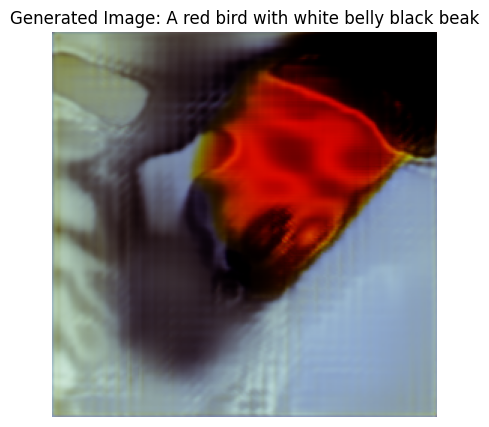

Saved generated images grid to: /kaggle/working/generated/bird.png/grid_bird.png


In [ ]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt

def generate_image_from_weights(generator, text_encoder, word_caption, gen_weights_path, save_path):
 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load generator weights
    checkpoint = torch.load(gen_weights_path, map_location=device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.to(device)
    generator.eval()

    # Get dataset vocabulary mapping (assuming train_loader is accessible)
    dataset = train_loader.dataset  # Original dataset object
    codes = [dataset.word2code.get(w, 0) for w in word_caption.lower().split()]  # Handle unknown words
    
    # Prepare padded caption tensor
    caption = np.array(codes)
    pad_caption = np.zeros((18, 1), dtype='int64')

    if len(caption) <= 18:
        pad_caption[:len(caption), 0] = caption
        len_ = len(caption)
    else:
        indices = np.random.permutation(len(caption))[:18]
        pad_caption[:, 0] = caption[np.sort(indices)]
        len_ = 18

    tensor1 = torch.tensor(pad_caption).reshape(1, -1).to(device)
    tensor2 = torch.tensor([len_]).to(device)

    # Encode text
    with torch.no_grad():
        embed, word = text_encoder(tensor1, tensor2)

        # Generate image
        noise = torch.randn(1, 100).to(device)
        img = generator(noise, embed, word)

    # Convert to numpy image format
    img_np = img[0].detach().cpu().numpy().transpose(1, 2, 0)

    # Normalize from [-1,1] to [0,255]
    img_np = ((img_np + 1) * 127.5).astype(np.uint8)

    # Ensure save directory exists
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Save image
    plt.imsave(save_path, img_np)

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)
    plt.axis("off")
    plt.title(f"Generated Image: {word_caption}")
    plt.show()


# Example Usage (if models are available)
gen_weights_path = "/kaggle/input/working/gennormal_35.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



train_loader = create_loader(256, 24, "/kaggle/input/cv-seattention/cv_seattention/data", "test")
n_words = train_loader.dataset.n_words

# Load text encoder
text_encoder = RNNEncoder.load("/kaggle/input/cv-seattention/cv_seattention/text_encoder_weights/text_encoder200.pth", n_words)


# Assuming you have an RNNEncoder class available
text_encoder = RNNEncoder.load("/kaggle/input/cv-seattention/cv_seattention/text_encoder_weights/text_encoder200.pth", n_words)
text_encoder.to(device)
text_encoder.eval()  # Set to eval mode

save_path = "/kaggle/working/generated/yellow_bird.png"
# caption = "A blue bird"
generator = Generator(n_channels=32, latent_dim=100).to(device)
generate_image_from_weights(generator, text_encoder, caption, gen_weights_path, save_path)


# start_time = time.time()

caption = "A red bird with white belly black beak"
generate_multiple_images(
    word_caption=caption,
    base_name="bird",
    num_images=16  # Will create 4x4 grid
)